In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim

In [5]:
time_step = np.linspace(0, 100, 500)
data = np.sin(time_step)
df = pd.DataFrame(data, columns=["value"])
df.head()

,value
0,0.000000
1,0.199062
2,0.390157
3,0.565634
4,0.718472


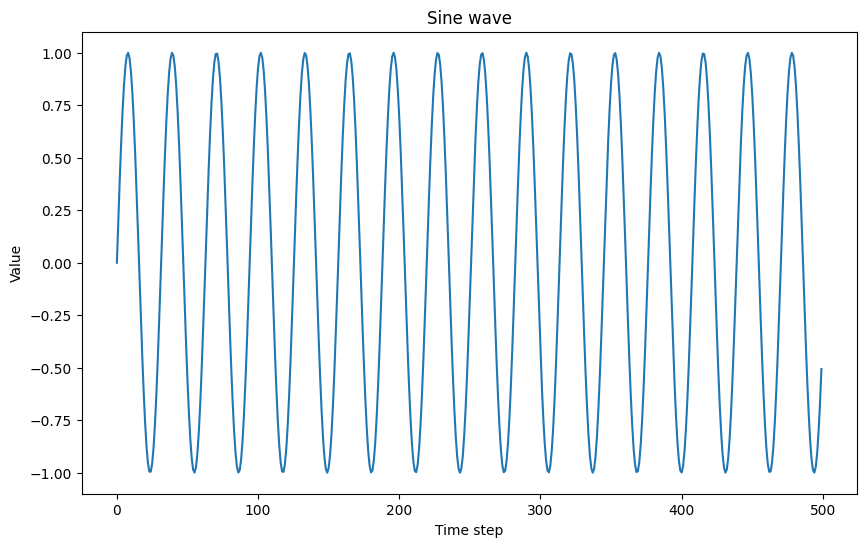

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(df['value'])
plt.title("Sine wave")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.show()

In [8]:
scaler = MinMaxScaler()
df['value'] = scaler.fit_transform(df[['value']])
data = df['value'].values

In [10]:
def create_sequences(data, seq_length):
  xs, ys = [], []
  for i in range(len(data) - seq_length):
    x = data[i:(i + seq_length)]
    y = data[i + seq_length]
    xs.append(x)
    ys.append(y)
  return np.array(xs), np.array(ys)


In [11]:
SEQ_LENGTH = 20
X, y = create_sequences(data, SEQ_LENGTH)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
X_train = torch.Tensor(X_train).unsqueeze(-1)
y_train = torch.Tensor(y_train)
X_test = torch.Tensor(X_test).unsqueeze(-1)
y_test = torch.Tensor(y_test)

In [13]:
class BasicRNN(nn.Module):
  def __init__(self, input_size = 1, hidden_size=64, num_layers=1):
    super(BasicRNN, self).__init__()
    self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
    self.fc = nn.Linear(hidden_size, 1)

  def forward(self, x):
    out, _ = self.rnn(x)
    out = out[:, -1, :]
    out = self.fc(out)
    return out

model = BasicRNN()

In [14]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
EPOCHS = 100
losses = []
for epoch in range(EPOCHS):
  model.train()
  output = model(X_train)
  loss = criterion(output.squeeze(), y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  losses.append(loss.item())

  if (epoch + 1) % 10 == 0:
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 0.0366
Epoch [20/100], Loss: 0.0151
Epoch [30/100], Loss: 0.0012
Epoch [40/100], Loss: 0.0003
Epoch [50/100], Loss: 0.0007
Epoch [60/100], Loss: 0.0019
Epoch [70/100], Loss: 0.0000
Epoch [80/100], Loss: 0.0001
Epoch [90/100], Loss: 0.0001
Epoch [100/100], Loss: 0.0000


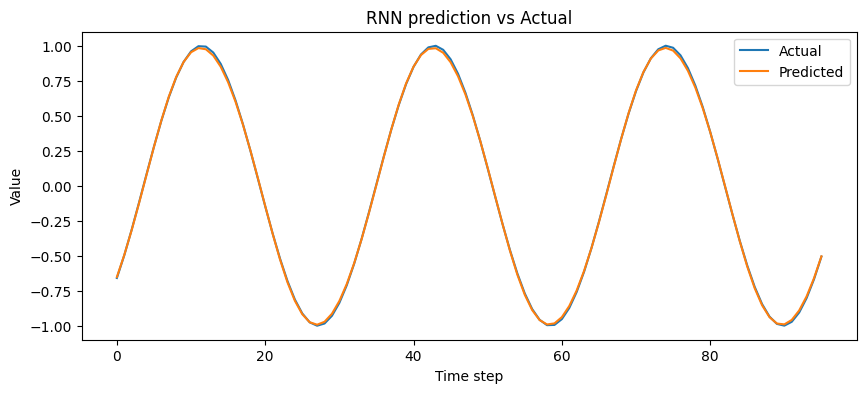

In [15]:
model.eval()
with torch.no_grad():
  predictions = model(X_test).squeeze().numpy()

y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
predictions_inv = scaler.inverse_transform(predictions.reshape(-1, 1))

plt.figure(figsize=(10, 4))
plt.plot(y_test_inv, label='Actual')
plt.plot(predictions_inv, label='Predicted')
plt.title("RNN prediction vs Actual")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.legend()
plt.show()

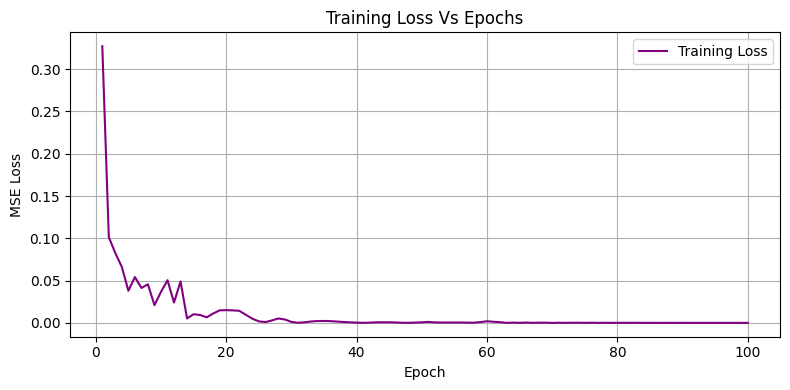

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 100 + 1), losses, label="Training Loss", color='purple')
plt.title("Training Loss Vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

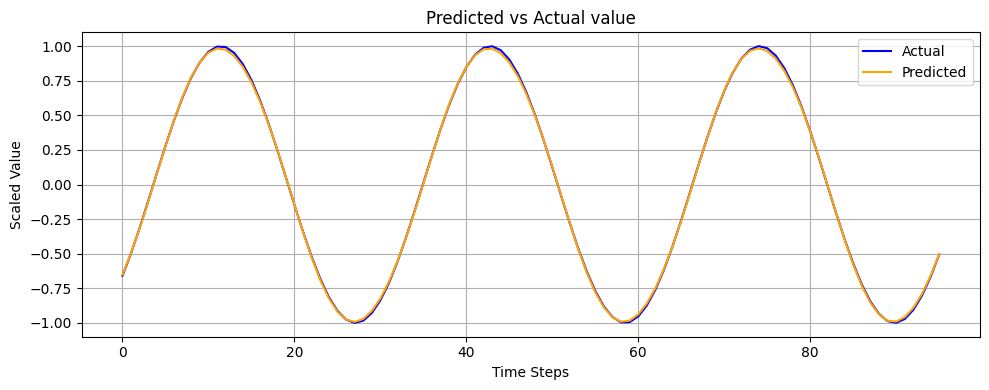

In [18]:
plt.figure(figsize=(10, 4))
plt.plot(y_test_inv, label="Actual", color='blue')
plt.plot(predictions_inv, label="Predicted", color='orange')
plt.title("Predicted vs Actual value")
plt.xlabel("Time Steps")
plt.ylabel("Scaled Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()